In [ ]:
# CELL 1: cài đặt thư viện
# Mục đích:
# - Cài Ultralytics
# - Gộp chung 1 lệnh để pip tự giải quyết xung đột ngay từ đầu

!pip -q install --upgrade pip
!pip -q install ultralytics pandas==2.2.2 numpy==2.0.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 40.5 MB/s eta 0:00:00


In [ ]:
# CELL 2: mount drive và khai báo đường dẫn
# Mục đích:
# - Mount Google Drive
# - Khai báo đường dẫn dataset YOLO từ Notebook 1
# - Khai báo thư mục lưu model / evaluation / summary

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

# ====== ROOT PATHS ======
PROJECT_ROOT = Path("/content/drive/MyDrive/Papaya_Leaf_Disease_Classification")
PREP_ROOT    = PROJECT_ROOT / "prepared_data_v1"
YOLO_DATASET = PREP_ROOT / "yolo_dataset"
DATA_YAML    = YOLO_DATASET / "dataset.yaml"

MODEL_ROOT   = PROJECT_ROOT / "Model"
YOLO_ROOT    = MODEL_ROOT / "YOLOv11"
EVAL_ROOT    = YOLO_ROOT / "test_evaluations"
REPORT_ROOT  = YOLO_ROOT / "reports"

for p in [MODEL_ROOT, YOLO_ROOT, EVAL_ROOT, REPORT_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT :", PROJECT_ROOT)
print("PREP_ROOT    :", PREP_ROOT)
print("YOLO_DATASET :", YOLO_DATASET)
print("DATA_YAML    :", DATA_YAML)
print("YOLO_ROOT    :", YOLO_ROOT)
print("EVAL_ROOT    :", EVAL_ROOT)
print("REPORT_ROOT  :", REPORT_ROOT)

assert YOLO_DATASET.exists(), f"Không tìm thấy YOLO dataset: {YOLO_DATASET}"
assert DATA_YAML.exists(), f"Không tìm thấy dataset.yaml: {DATA_YAML}"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_ROOT : /content/drive/MyDrive/Papaya_Leaf_Disease_Classification
PREP_ROOT    : /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/prepared_data_v1
YOLO_DATASET : /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/prepared_data_v1/yolo_dataset
DATA_YAML    : /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/prepared_data_v1/yolo_dataset/dataset.yaml
YOLO_ROOT    : /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/YOLOv11
EVAL_ROOT    : /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/YOLOv11/test_evaluations
REPORT_ROOT  : /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/YOLOv11/reports


In [ ]:
# CELL 3: import thư viện và cấu hình train
# Mục đích:
# - Import thư viện
# - Thiết lập cấu hình train/resume/evaluate
# - Cấu hình model list và hyperparameter

import os
import sys
import json
import time
import math
import yaml
import shutil
import random
import warnings
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from tqdm.auto import tqdm
from ultralytics import YOLO

warnings.filterwarnings("ignore")
os.environ["WANDB_DISABLED"] = "true"

# ====== SEED ======
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ====== DEVICE ======
DEVICE = 0 if torch.cuda.is_available() else "cpu"

# ====== MODEL LIST ======
MODEL_SPECS = {
    "YOLOv11n": "yolo11n.pt",
    "YOLOv11s": "yolo11s.pt",
    "YOLOv11m": "yolo11m.pt",
}

MODELS_TO_RUN = ["YOLOv11n", "YOLOv11s", "YOLOv11m"]

# ====== TRAIN CONFIG ======
EPOCHS = 80
IMG_SIZE = 832
PATIENCE = 20
CLOSE_MOSAIC = 10
WORKERS = 2
SAVE = True
SAVE_PERIOD = -1           # -1 = chỉ save mặc định của Ultralytics
PLOTS = True
VERBOSE = True
COS_LR = True
RECT = False
AMP = True
CACHE = False
OVERLAP_MASK = False       # không dùng cho detect nhưng để rõ ý
PRETRAINED = True
OPTIMIZER = "auto"

# Batch theo model để tránh OOM trên T4 16GB
BATCH_MAP = {
    "YOLOv11n": 16,
    "YOLOv11s": 12,
    "YOLOv11m": 8,
}

# ====== AUGMENT CONFIG ======
AUGMENT_ARGS = {
    "degrees": 5.0,
    "translate": 0.05,
    "scale": 0.20,
    "fliplr": 0.50,
    "flipud": 0.10,
    "mosaic": 1.0,
    "mixup": 0.0,
    "copy_paste": 0.0,
}

# ====== RESUME / SKIP CONFIG ======
SKIP_IF_BEST_EXISTS = True
RESUME_IF_LAST_EXISTS = True
FORCE_RETRAIN = False

# ====== EVAL CONFIG ======
EVAL_IMG_SIZE = IMG_SIZE
EVAL_BATCH = 8
EVAL_CONF = 0.25
EVAL_IOU = 0.70
SAVE_TEST_PLOTS = True

# ====== REPORT FILES ======
TRAIN_SUMMARY_CSV = REPORT_ROOT / "train_summary.csv"
TEST_SUMMARY_CSV  = REPORT_ROOT / "test_summary.csv"
FINAL_SUMMARY_CSV = REPORT_ROOT / "final_yolo_comparison.csv"
FINAL_SUMMARY_JSON = REPORT_ROOT / "final_yolo_comparison.json"

print("Torch version       :", torch.__version__)
print("CUDA available      :", torch.cuda.is_available())
print("CUDA device count   :", torch.cuda.device_count())
print("DEVICE              :", DEVICE)
if torch.cuda.is_available():
    print("GPU name            :", torch.cuda.get_device_name(0))

print("\nMODELS_TO_RUN       :", MODELS_TO_RUN)
print("BATCH_MAP           :", BATCH_MAP)
print("EPOCHS              :", EPOCHS)
print("IMG_SIZE            :", IMG_SIZE)
print("PATIENCE            :", PATIENCE)

Torch version       : 2.10.0+cu128
CUDA available      : True
CUDA device count   : 1
DEVICE              : 0
GPU name            : Tesla T4

MODELS_TO_RUN       : ['YOLOv11n', 'YOLOv11s', 'YOLOv11m']
BATCH_MAP           : {'YOLOv11n': 16, 'YOLOv11s': 12, 'YOLOv11m': 8}
EPOCHS              : 80
IMG_SIZE            : 832
PATIENCE            : 20


In [ ]:
# CELL 4: kiểm tra dataset YOLO trước khi train
# Mục đích:
# - Kiểm tra dataset.yaml
# - Kiểm tra số lượng image/label theo split
# - In warning nếu thiếu file tương ứng

import glob

with open(DATA_YAML, "r", encoding="utf-8") as f:
    data_yaml = yaml.safe_load(f)

print("===== DATA_YAML CONTENT =====")
print(json.dumps(data_yaml, indent=2, ensure_ascii=False))

required_keys = ["path", "train", "val", "test", "names"]
for k in required_keys:
    assert k in data_yaml, f"dataset.yaml thiếu key: {k}"

dataset_root = Path(data_yaml["path"])
assert dataset_root.exists(), f"dataset root không tồn tại: {dataset_root}"

def list_files(folder: Path, exts):
    out = []
    for p in folder.rglob("*"):
        if p.is_file() and p.suffix.lower() in exts:
            out.append(p)
    return sorted(out)

def split_sanity(split_name: str):
    img_dir = dataset_root / "images" / split_name
    lbl_dir = dataset_root / "labels" / split_name

    assert img_dir.exists(), f"Thiếu thư mục ảnh split={split_name}: {img_dir}"
    assert lbl_dir.exists(), f"Thiếu thư mục label split={split_name}: {lbl_dir}"

    imgs = list_files(img_dir, {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"})
    lbls = list_files(lbl_dir, {".txt"})

    img_stems = set(p.stem for p in imgs)
    lbl_stems = set(p.stem for p in lbls)

    missing_labels = sorted(img_stems - lbl_stems)
    orphan_labels  = sorted(lbl_stems - img_stems)

    return {
        "split": split_name,
        "num_images": len(imgs),
        "num_labels": len(lbls),
        "missing_labels": missing_labels,
        "orphan_labels": orphan_labels,
        "image_dir": str(img_dir),
        "label_dir": str(lbl_dir),
    }

sanity_rows = []
sanity_details = {}

for split_name in ["train", "val", "test"]:
    info = split_sanity(split_name)
    sanity_rows.append({
        "split": info["split"],
        "num_images": info["num_images"],
        "num_labels": info["num_labels"],
        "num_missing_labels": len(info["missing_labels"]),
        "num_orphan_labels": len(info["orphan_labels"]),
    })
    sanity_details[split_name] = info

sanity_df = pd.DataFrame(sanity_rows)
display(sanity_df)

sanity_df.to_csv(REPORT_ROOT / "dataset_split_sanity.csv", index=False, encoding="utf-8-sig")
with open(REPORT_ROOT / "dataset_split_sanity_details.json", "w", encoding="utf-8") as f:
    json.dump(sanity_details, f, indent=2, ensure_ascii=False)

for split_name in ["train", "val", "test"]:
    info = sanity_details[split_name]
    if info["missing_labels"] or info["orphan_labels"]:
        print(f"\n[WARNING] split={split_name}")
        print("  missing_labels:", len(info["missing_labels"]))
        print("  orphan_labels :", len(info["orphan_labels"]))
    else:
        print(f"[OK] split={split_name}: image/label khớp số lượng theo stem")

print("\nNếu split nào có mismatch lớn hoặc label lỗi nặng, train có thể fail.")

===== DATA_YAML CONTENT =====
{
  "path": "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/prepared_data_v1/yolo_dataset",
  "train": "images/train",
  "val": "images/val",
  "test": "images/test",
  "names": {
    "0": "Anthracnose",
    "1": "BacterialSpot",
    "2": "Curl",
    "3": "RingSpot"
  }
}


,split,num_images,num_labels,num_missing_labels,num_orphan_labels
0,train,1194,1194,0,0
1,val,256,256,0,0
2,test,257,257,0,0


[OK] split=train: image/label khớp số lượng theo stem
[OK] split=val: image/label khớp số lượng theo stem
[OK] split=test: image/label khớp số lượng theo stem

Nếu split nào có mismatch lớn hoặc label lỗi nặng, train có thể fail.


In [ ]:
# CELL 5: hàm tiện ích cho train / resume / export metric
# Mục đích:
# - Định nghĩa các hàm dùng chung cho train/eval
# - Trích xuất metrics và lưu báo cáo

def ensure_dir(path: Path):
    path.mkdir(parents=True, exist_ok=True)

def safe_float(x, default=np.nan):
    try:
        return float(x)
    except Exception:
        return default

def model_run_dir(model_alias: str) -> Path:
    return YOLO_ROOT / model_alias

def weights_dir(model_alias: str) -> Path:
    return model_run_dir(model_alias) / "weights"

def best_ckpt_path(model_alias: str) -> Path:
    return weights_dir(model_alias) / "best.pt"

def last_ckpt_path(model_alias: str) -> Path:
    return weights_dir(model_alias) / "last.pt"

def results_csv_path(model_alias: str) -> Path:
    return model_run_dir(model_alias) / "results.csv"

def train_args_for(model_alias: str):
    return {
        "data": str(DATA_YAML),
        "epochs": EPOCHS,
        "imgsz": IMG_SIZE,
        "batch": BATCH_MAP[model_alias],
        "device": DEVICE,
        "workers": WORKERS,
        "project": str(YOLO_ROOT),
        "name": model_alias,
        "exist_ok": True,
        "patience": PATIENCE,
        "save": SAVE,
        "save_period": SAVE_PERIOD,
        "plots": PLOTS,
        "verbose": VERBOSE,
        "seed": SEED,
        "optimizer": OPTIMIZER,
        "pretrained": PRETRAINED,
        "cos_lr": COS_LR,
        "close_mosaic": CLOSE_MOSAIC,
        "amp": AMP,
        "cache": CACHE,
        "rect": RECT,
        **AUGMENT_ARGS,
    }

def read_results_csv_if_exists(model_alias: str):
    csv_path = results_csv_path(model_alias)
    if csv_path.exists():
        try:
            return pd.read_csv(csv_path)
        except Exception:
            return None
    return None

def get_last_epoch_from_results(model_alias: str):
    df = read_results_csv_if_exists(model_alias)
    if df is None or len(df) == 0:
        return None
    if "epoch" in df.columns:
        try:
            return int(df["epoch"].max())
        except Exception:
            return None
    return len(df) - 1

def extract_train_curve_summary(model_alias: str):
    df = read_results_csv_if_exists(model_alias)
    if df is None or len(df) == 0:
        return {}

    summary = {"num_logged_epochs": len(df)}

    candidate_cols = [
        "train/box_loss", "train/cls_loss", "train/dfl_loss",
        "val/box_loss", "val/cls_loss", "val/dfl_loss",
        "metrics/precision(B)", "metrics/recall(B)",
        "metrics/mAP50(B)", "metrics/mAP50-95(B)"
    ]

    for col in candidate_cols:
        if col in df.columns:
            summary[f"last_{col}"] = safe_float(df[col].iloc[-1])

    if "metrics/mAP50-95(B)" in df.columns:
        best_idx = df["metrics/mAP50-95(B)"].astype(float).idxmax()
        summary["best_epoch_by_map5095"] = int(df.loc[best_idx, "epoch"]) if "epoch" in df.columns else int(best_idx)
        summary["best_map5095"] = safe_float(df.loc[best_idx, "metrics/mAP50-95(B)"])

    return summary

def save_dict_json(obj: dict, path: Path):
    ensure_dir(path.parent)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False)

def maybe_to_pandas(df_like):
    if df_like is None:
        return None
    if isinstance(df_like, pd.DataFrame):
        return df_like
    if hasattr(df_like, "to_pandas"):
        try:
            return df_like.to_pandas()
        except Exception:
            pass
    try:
        return pd.DataFrame(df_like)
    except Exception:
        return None

def extract_val_metrics(metrics, model_alias: str, ckpt_path: Path, split_name: str):
    row = {
        "model_alias": model_alias,
        "checkpoint_path": str(ckpt_path),
        "split": split_name,
        "mp": np.nan,
        "mr": np.nan,
        "map50": np.nan,
        "map75": np.nan,
        "map50_95": np.nan,
        "speed_preprocess_ms": np.nan,
        "speed_inference_ms": np.nan,
        "speed_loss_ms": np.nan,
        "speed_postprocess_ms": np.nan,
    }

    try:
        box = getattr(metrics, "box", None)
        if box is not None:
            row["mp"] = safe_float(getattr(box, "mp", np.nan))
            row["mr"] = safe_float(getattr(box, "mr", np.nan))
            row["map50"] = safe_float(getattr(box, "map50", np.nan))
            row["map75"] = safe_float(getattr(box, "map75", np.nan))
            row["map50_95"] = safe_float(getattr(box, "map", np.nan))
    except Exception:
        pass

    try:
        speed = getattr(metrics, "speed", None)
        if isinstance(speed, dict):
            row["speed_preprocess_ms"] = safe_float(speed.get("preprocess", np.nan))
            row["speed_inference_ms"] = safe_float(speed.get("inference", np.nan))
            row["speed_loss_ms"] = safe_float(speed.get("loss", np.nan))
            row["speed_postprocess_ms"] = safe_float(speed.get("postprocess", np.nan))
    except Exception:
        pass

    return row

def save_confusion_matrix_if_possible(metrics, out_csv_path: Path):
    try:
        cm = getattr(metrics, "confusion_matrix", None)
        if cm is None:
            return False
        cm_df = maybe_to_pandas(cm.to_df())
        if cm_df is None:
            return False
        cm_df.to_csv(out_csv_path, index=False, encoding="utf-8-sig")
        return True
    except Exception:
        return False

def save_per_class_summary_if_possible(metrics, out_csv_path: Path):
    try:
        summary_obj = metrics.summary()
        df = maybe_to_pandas(summary_obj)
        if df is None:
            return False
        df.to_csv(out_csv_path, index=False, encoding="utf-8-sig")
        return True
    except Exception:
        return False

def train_or_resume_model(model_alias: str):
    model_weight = MODEL_SPECS[model_alias]
    run_dir = model_run_dir(model_alias)
    best_pt = best_ckpt_path(model_alias)
    last_pt = last_ckpt_path(model_alias)

    ensure_dir(run_dir)

    status = {
        "model_alias": model_alias,
        "run_dir": str(run_dir),
        "best_pt": str(best_pt),
        "last_pt": str(last_pt),
        "action": None,
        "success": False,
        "error": None,
        "start_time": time.strftime("%Y-%m-%d %H:%M:%S"),
    }

    try:
        if FORCE_RETRAIN:
            model = YOLO(model_weight)
            status["action"] = "force_retrain_new_run"
            model.train(**train_args_for(model_alias))

        elif SKIP_IF_BEST_EXISTS and best_pt.exists():
            status["action"] = "skip_existing_best"

        elif RESUME_IF_LAST_EXISTS and last_pt.exists():
            model = YOLO(str(last_pt))
            status["action"] = "resume_from_last"
            model.train(resume=True)

        else:
            model = YOLO(model_weight)
            status["action"] = "fresh_train_from_pretrained"
            model.train(**train_args_for(model_alias))

        status["success"] = True
        status["end_time"] = time.strftime("%Y-%m-%d %H:%M:%S")
        status["last_logged_epoch"] = get_last_epoch_from_results(model_alias)
        status.update(extract_train_curve_summary(model_alias))
        return status

    except Exception as e:
        status["success"] = False
        status["error"] = str(e)
        status["end_time"] = time.strftime("%Y-%m-%d %H:%M:%S")
        return status

def evaluate_model_on_test(model_alias: str):
    best_pt = best_ckpt_path(model_alias)
    assert best_pt.exists(), f"Không tìm thấy best.pt cho {model_alias}: {best_pt}"

    eval_dir = EVAL_ROOT / model_alias
    ensure_dir(eval_dir)

    model = YOLO(str(best_pt))
    metrics = model.val(
        data=str(DATA_YAML),
        split="test",
        imgsz=EVAL_IMG_SIZE,
        batch=EVAL_BATCH,
        conf=EVAL_CONF,
        iou=EVAL_IOU,
        device=DEVICE,
        workers=WORKERS,
        plots=SAVE_TEST_PLOTS,
        project=str(EVAL_ROOT),
        name=model_alias,
        exist_ok=True,
        verbose=True,
    )

    metric_row = extract_val_metrics(metrics, model_alias, best_pt, split_name="test")

    save_confusion_matrix_if_possible(metrics, eval_dir / "confusion_matrix_test.csv")
    save_per_class_summary_if_possible(metrics, eval_dir / "per_class_metrics_test.csv")
    save_dict_json(metric_row, eval_dir / "test_metrics_summary.json")

    return metric_row

print("Utility functions ready.")

Utility functions ready.


In [ ]:
# CELL 6: train lần lượt YOLOv11n, YOLOv11s, YOLOv11m
# Mục đích:
# - Train tuần tự từng model
# - Nếu best.pt đã có thì skip
# - Nếu có last.pt thì resume

train_logs = []

for model_alias in MODELS_TO_RUN:
    print("\n" + "=" * 80)
    print(f"TRAINING MODEL: {model_alias}")
    print("=" * 80)

    print("run_dir :", model_run_dir(model_alias))
    print("best_pt :", best_ckpt_path(model_alias))
    print("last_pt :", last_ckpt_path(model_alias))
    print("batch   :", BATCH_MAP[model_alias])

    log_row = train_or_resume_model(model_alias)
    train_logs.append(log_row)

    print("\nTrain status:")
    print(json.dumps(log_row, indent=2, ensure_ascii=False))

train_logs_df = pd.DataFrame(train_logs)
train_logs_df.to_csv(TRAIN_SUMMARY_CSV, index=False, encoding="utf-8-sig")

print("\n===== TRAIN SUMMARY =====")
display(train_logs_df)
print("Saved to:", TRAIN_SUMMARY_CSV)


TRAINING MODEL: YOLOv11n
run_dir : /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/YOLOv11/YOLOv11n
best_pt : /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/YOLOv11/YOLOv11n/weights/best.pt
last_pt : /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/YOLOv11/YOLOv11n/weights/last.pt
batch   : 16
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/prepared_data_v1/yolo_dataset/dataset.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0

In [ ]:
from pathlib import Path

YOLO_M_BEST = Path("/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/YOLOv11/YOLOv11m/weights/best.pt")
YOLO_M_LAST = Path("/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/YOLOv11/YOLOv11m/weights/last.pt")

print("best exists:", YOLO_M_BEST.exists(), YOLO_M_BEST)
print("last exists:", YOLO_M_LAST.exists(), YOLO_M_LAST)

best exists: False /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/YOLOv11/YOLOv11m/weights/best.pt
last exists: False /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/YOLOv11/YOLOv11m/weights/last.pt


In [ ]:
from pathlib import Path

search_roots = [
    Path("/content/drive/MyDrive"),
    Path("/content/drive/.shortcut-targets-by-id"),
]

candidates = []
for root in search_roots:
    if root.exists():
        candidates.extend(root.rglob("Papaya_Leaf_Disease_Classification/Model/YOLOv11/YOLOv11m/weights/best.pt"))
        candidates.extend(root.rglob("Papaya_Leaf_Disease_Classification/Model/YOLOv11/YOLOv11m/weights/last.pt"))

print("Found checkpoints:")
for p in candidates:
    print(p)

Found checkpoints:


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
!pip -q install ultralytics
from pathlib import Path
from ultralytics import YOLO

DATA_YAML = "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/prepared_data_v1/yolo_dataset/dataset.yaml"
EVAL_ROOT = "/content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/YOLOv11/test_evaluations"

search_roots = [
    Path("/content/drive/MyDrive"),
    Path("/content/drive/.shortcut-targets-by-id"),
]

best_candidates = []
last_candidates = []

for root in search_roots:
    if root.exists():
        best_candidates.extend(root.rglob("Papaya_Leaf_Disease_Classification/Model/YOLOv11/YOLOv11m/weights/best.pt"))
        last_candidates.extend(root.rglob("Papaya_Leaf_Disease_Classification/Model/YOLOv11/YOLOv11m/weights/last.pt"))

best_candidates = sorted(set(best_candidates))
last_candidates = sorted(set(last_candidates))

print("best_candidates:")
for p in best_candidates:
    print(" -", p)

print("\nlast_candidates:")
for p in last_candidates:
    print(" -", p)

if best_candidates:
    CKPT_PATH = str(best_candidates[0])
    print(f"\nUsing best.pt: {CKPT_PATH}")
elif last_candidates:
    CKPT_PATH = str(last_candidates[0])
    print(f"\nKhông tìm thấy best.pt, dùng last.pt: {CKPT_PATH}")
else:
    raise FileNotFoundError("Không tìm thấy cả best.pt lẫn last.pt cho YOLOv11m")

model = YOLO(CKPT_PATH)

metrics = model.val(
    data=DATA_YAML,
    split="test",
    imgsz=832,
    batch=8,
    conf=0.25,
    iou=0.70,
    device=0,
    workers=2,
    plots=True,
    project=EVAL_ROOT,
    name="YOLOv11m",
    exist_ok=True,
    verbose=True,
)

print("\n===== TEST METRICS =====")
print("Precision :", metrics.box.mp)
print("Recall    :", metrics.box.mr)
print("mAP50     :", metrics.box.map50)
print("mAP50-95  :", metrics.box.map)

Mounted at /content/drive
best_candidates:
 - /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/YOLOv11/YOLOv11m/weights/best.pt

last_candidates:
 - /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/YOLOv11/YOLOv11m/weights/last.pt

Using best.pt: /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/YOLOv11/YOLOv11m/weights/best.pt
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m summary (fused): 126 layers, 20,033,116 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access ✅ (ping: 0.9±0.5 ms, read: 0.2±0.1 MB/s, size: 99.1 KB)
val: Scanning /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/prepared_data_v1/yolo_dataset/labels/test... 257 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 257/257 3.4it/s 1:16
val: New cache created: /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/prepared_data_v1/yolo_dataset/labels/test.cache
                 Class     Images  Instances      Box(P

In [ ]:
# CELL 7: evaluate trên test set cho từng model
# Mục đích:
# - Dùng best.pt của từng model để evaluate trên test split
# - Lưu metric + confusion matrix + per-class metrics

test_logs = []

for model_alias in MODELS_TO_RUN:
    print("\n" + "=" * 80)
    print(f"TEST EVALUATION: {model_alias}")
    print("=" * 80)

    best_pt = best_ckpt_path(model_alias)
    if not best_pt.exists():
        print(f"[SKIP] Không có best.pt cho {model_alias}")
        test_logs.append({
            "model_alias": model_alias,
            "checkpoint_path": str(best_pt),
            "split": "test",
            "mp": np.nan,
            "mr": np.nan,
            "map50": np.nan,
            "map75": np.nan,
            "map50_95": np.nan,
            "speed_preprocess_ms": np.nan,
            "speed_inference_ms": np.nan,
            "speed_loss_ms": np.nan,
            "speed_postprocess_ms": np.nan,
            "status": "missing_best_checkpoint",
        })
        continue

    try:
        row = evaluate_model_on_test(model_alias)
        row["status"] = "ok"
        test_logs.append(row)
        print(json.dumps(row, indent=2, ensure_ascii=False))
    except Exception as e:
        err_row = {
            "model_alias": model_alias,
            "checkpoint_path": str(best_pt),
            "split": "test",
            "mp": np.nan,
            "mr": np.nan,
            "map50": np.nan,
            "map75": np.nan,
            "map50_95": np.nan,
            "speed_preprocess_ms": np.nan,
            "speed_inference_ms": np.nan,
            "speed_loss_ms": np.nan,
            "speed_postprocess_ms": np.nan,
            "status": f"error: {e}",
        }
        test_logs.append(err_row)
        print("[ERROR]", e)

test_logs_df = pd.DataFrame(test_logs)
test_logs_df.to_csv(TEST_SUMMARY_CSV, index=False, encoding="utf-8-sig")

print("\n===== TEST SUMMARY =====")
display(test_logs_df)
print("Saved to:", TEST_SUMMARY_CSV)


TEST EVALUATION: YOLOv11n
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 1.5±1.5 ms, read: 33.6±27.8 MB/s, size: 112.0 KB)
val: Scanning /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/prepared_data_v1/yolo_dataset/labels/test.cache... 257 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 257/257 63.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 33/33 5.3it/s 6.2s
                   all        257       1816      0.746      0.756      0.747      0.613
           Anthracnose         54       1054       0.62      0.513       0.48      0.284
         BacterialSpot         69         69      0.793          1      0.995      0.899
                  Curl         54         54      0.836          1      0.995      0.918
              RingSpot         80       

,model_alias,checkpoint_path,split,mp,mr,map50,map75,map50_95,speed_preprocess_ms,speed_inference_ms,speed_loss_ms,speed_postprocess_ms,status
0,YOLOv11n,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,test,0.746051,0.756255,0.747057,0.656775,0.612591,2.838539,7.244770,0.004308,2.705835,ok
1,YOLOv11s,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,test,0.813172,0.808875,0.765706,0.683826,0.644643,2.408904,10.830632,0.001976,2.199119,ok
2,YOLOv11m,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,test,0.802425,0.816155,0.776700,0.697640,0.652018,1.896716,29.663122,0.006839,1.329286,ok


Saved to: /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/YOLOv11/reports/test_summary.csv


===== FINAL YOLO COMPARISON =====


,model_alias,checkpoint_path,split,mp,mr,map50,map75,map50_95,speed_preprocess_ms,speed_inference_ms,speed_loss_ms,speed_postprocess_ms,status
0,YOLOv11m,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,test,0.802425,0.816155,0.776700,0.697640,0.652018,1.896716,29.663122,0.006839,1.329286,ok
1,YOLOv11s,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,test,0.813172,0.808875,0.765706,0.683826,0.644643,2.408904,10.830632,0.001976,2.199119,ok
2,YOLOv11n,/content/drive/MyDrive/Papaya_Leaf_Disease_Cla...,test,0.746051,0.756255,0.747057,0.656775,0.612591,2.838539,7.244770,0.004308,2.705835,ok



Saved:
 - /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/YOLOv11/reports/final_yolo_comparison.csv
 - /content/drive/MyDrive/Papaya_Leaf_Disease_Classification/Model/YOLOv11/reports/final_yolo_comparison.json


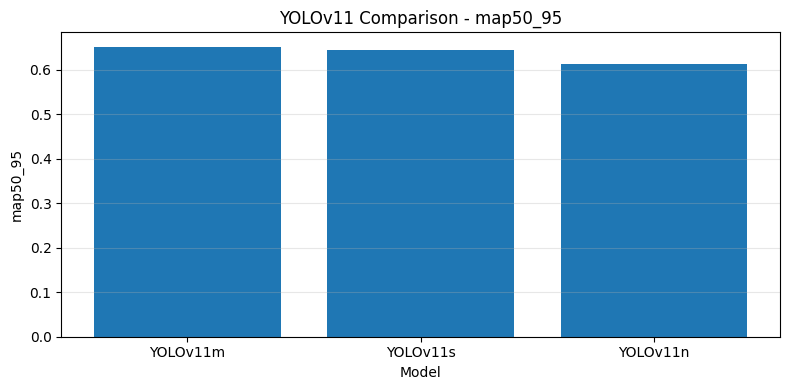

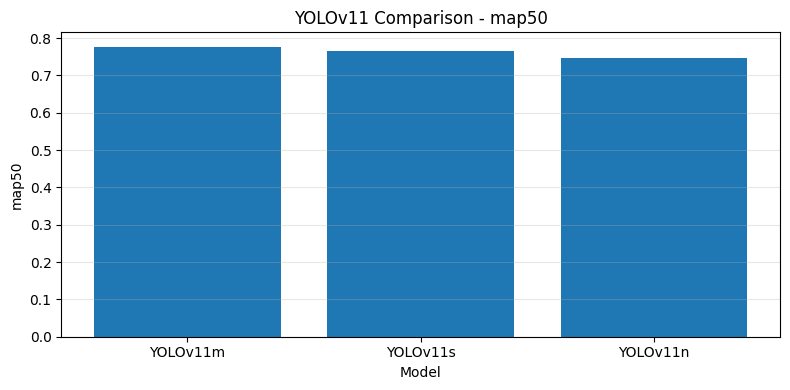

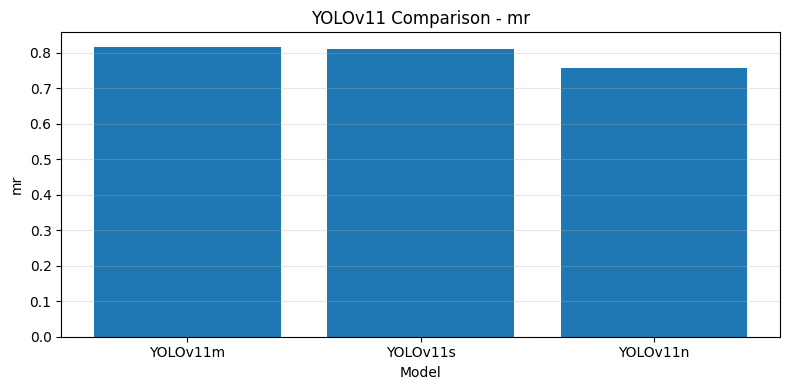

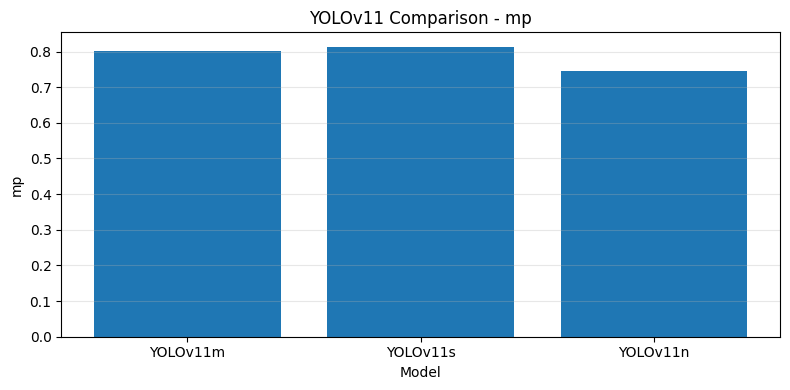

In [ ]:
# CELL 8: tổng hợp kết quả và so sánh các model
# Mục đích:
# - Gộp train log + test metric thành 1 bảng tổng hợp
# - Sắp xếp theo mAP50-95 và recall
# - Lưu CSV/JSON + vẽ biểu đồ cơ bản

train_df = pd.read_csv(TRAIN_SUMMARY_CSV) if TRAIN_SUMMARY_CSV.exists() else pd.DataFrame()
test_df  = pd.read_csv(TEST_SUMMARY_CSV) if TEST_SUMMARY_CSV.exists() else pd.DataFrame()

if len(train_df) > 0 and len(test_df) > 0:
    final_df = test_df.merge(
        train_df[["model_alias", "action", "success", "last_logged_epoch"]].copy(),
        on="model_alias",
        how="left"
    )
elif len(test_df) > 0:
    final_df = test_df.copy()
else:
    final_df = pd.DataFrame()

if len(final_df) > 0:
    final_df = final_df.sort_values(
        by=["map50_95", "mr", "map50"],
        ascending=[False, False, False]
    ).reset_index(drop=True)

final_df.to_csv(FINAL_SUMMARY_CSV, index=False, encoding="utf-8-sig")
with open(FINAL_SUMMARY_JSON, "w", encoding="utf-8") as f:
    json.dump(final_df.to_dict(orient="records"), f, indent=2, ensure_ascii=False)

print("===== FINAL YOLO COMPARISON =====")
display(final_df)

print("\nSaved:")
print(" -", FINAL_SUMMARY_CSV)
print(" -", FINAL_SUMMARY_JSON)

# ====== PLOT ======
if len(final_df) > 0:
    plot_df = final_df.copy()

    metrics_to_plot = ["map50_95", "map50", "mr", "mp"]
    for metric_name in metrics_to_plot:
        if metric_name in plot_df.columns:
            plt.figure(figsize=(8, 4))
            plt.bar(plot_df["model_alias"], plot_df[metric_name])
            plt.title(f"YOLOv11 Comparison - {metric_name}")
            plt.xlabel("Model")
            plt.ylabel(metric_name)
            plt.grid(axis="y", alpha=0.3)
            plt.tight_layout()
            plt.show()